In [29]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import constants as cst
import sys, os, git
import warnings
warnings.filterwarnings("ignore")

In [30]:
current_path = os.getcwd()
git_repo = git.Repo(current_path, search_parent_directories=True)
git_path = git_repo.git.rev_parse("--show-toplevel")
path_figures = current_path[len(git_path):] + '/'
path_in_folder = current_path[len(git_path)+1:]

In [31]:
sys.path.append(git_path + "/.submodules/pyplot-perso")
from plttools import PltTools

In [32]:
cmap_cool = cm.cool
cmap_dark_blue_to_cyan = LinearSegmentedColormap.from_list('dark_blue_to_cyan', ['#1D11CB', cmap_cool(0.0)])
cmap_viridis = cm.viridis      # excellent general-purpose
cmap_cividis = cm.cividis      # best for accessibility (colorblind-safe)
cmap_turbo   = cm.turbo        # very high contrast, vivid range
cmap_plasma  = cm.plasma       # strong contrast, warm highlights
cmap_inferno = cm.inferno      # dark-to-bright, great on dark BG
cmap_magma   = cm.magma        # smoother dark-background readability

cmap_cool = cm.cool
cmap_cyan_to_green_blue = LinearSegmentedColormap.from_list(
    "cyan_to_green_blue", ["#0f55eb", "#00FFFF", "#00FA9A"])

  Pixels: width = 700.8 x height = 682.9
  Aspect ratio: 1.0261
  Pixels: width = 700.8 x height = 682.9
  Aspect ratio: 1.0261


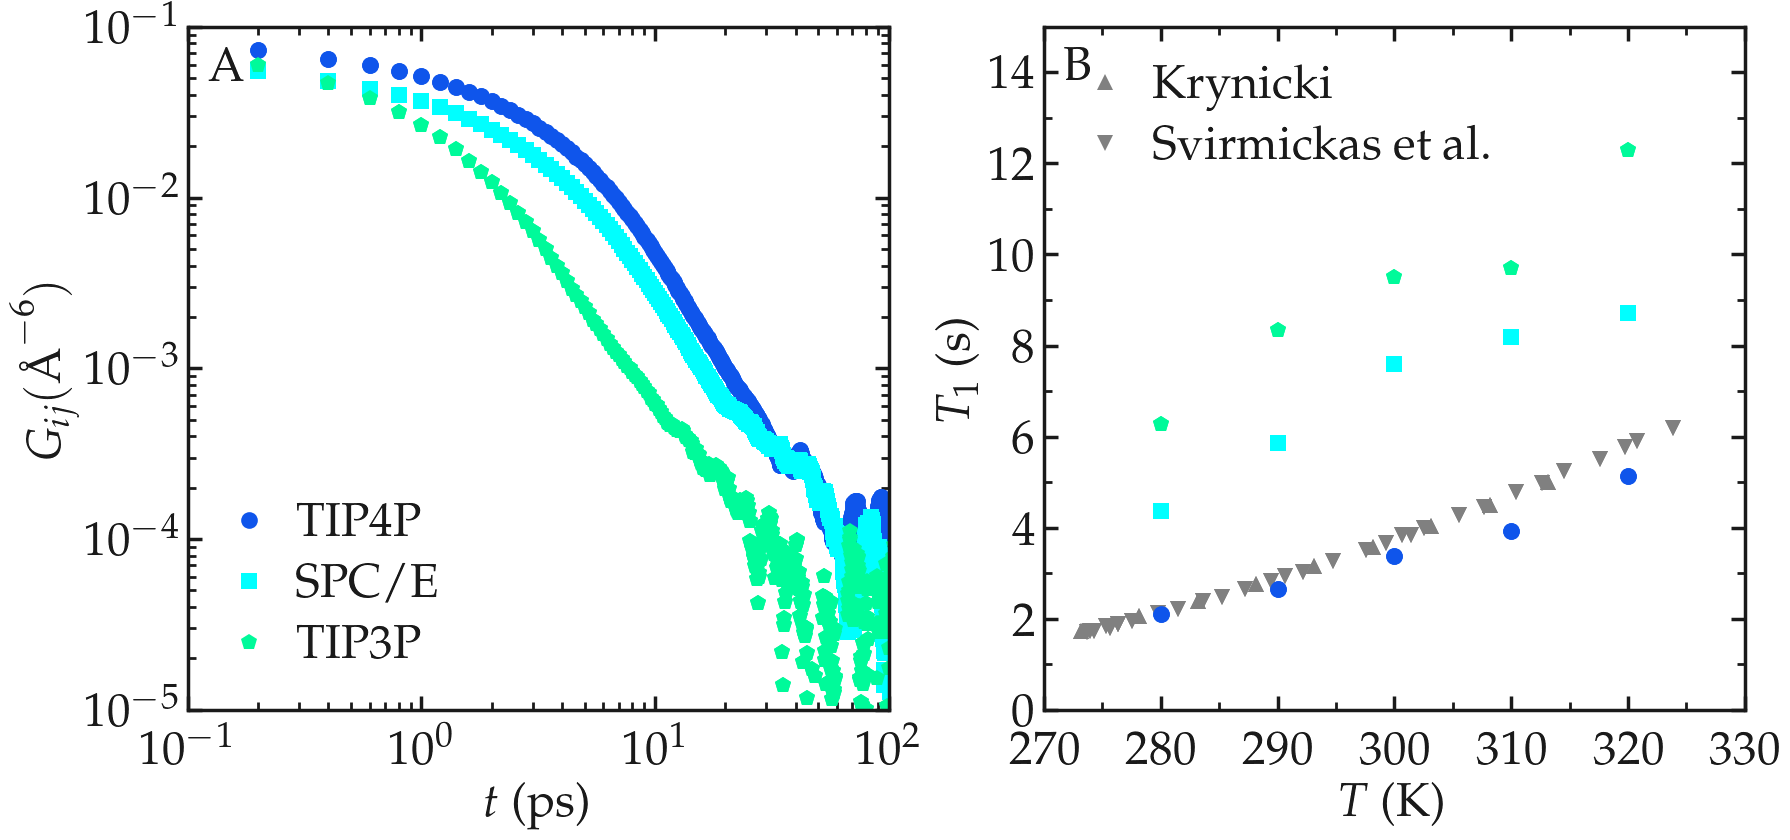

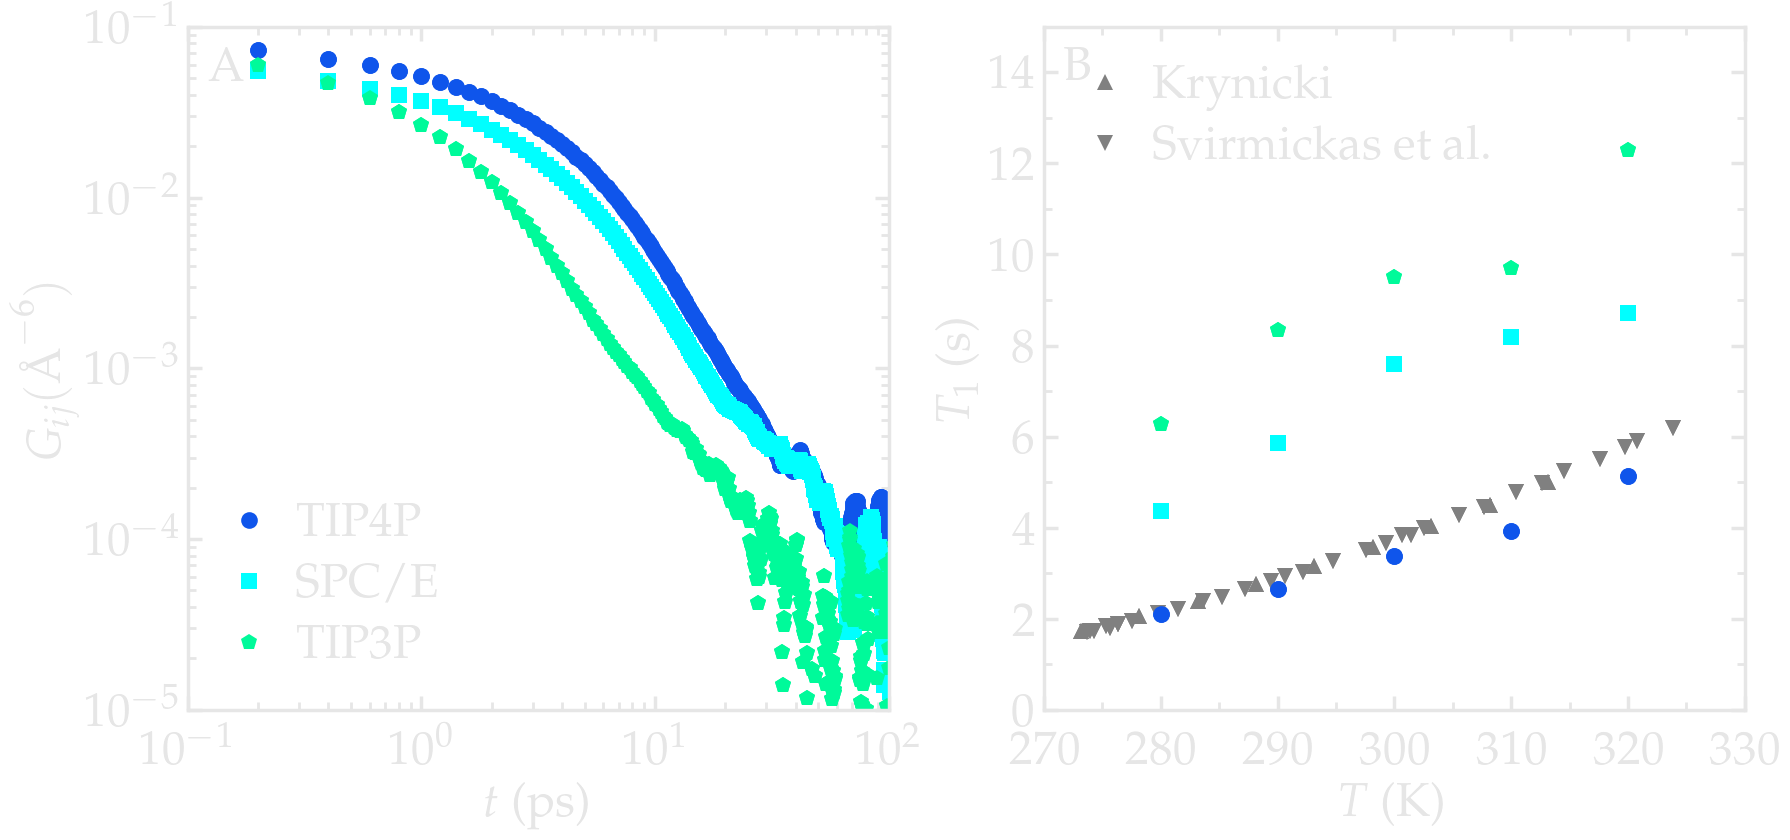

In [33]:
n = 500
type = "full"

for dark_mode in [False, True]:

    myplt = PltTools()
    myplt.prepare_figure(fig_size = (18, 8.5), dark_mode = dark_mode,
                         transparency = True, use_serif=True, n_colone = 2)
    
    # Panel 1
    colors = cmap_cyan_to_green_blue(np.linspace(0, 1, 3))

    myplt.add_panel()

    t, GT = np.loadtxt("water-ff/GT_T300K_TIP4P.dat").T
    t, GR = np.loadtxt("water-ff/GR_T300K_TIP4P.dat").T
    myplt.add_plot(x = t, y = GT+GR, type = "loglog", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3],
                markersize = 12, data_label = r'TIP4P')
    
    t, GT = np.loadtxt("water-ff/GT_T300K_SPCE.dat").T
    t, GR = np.loadtxt("water-ff/GR_T300K_SPCE.dat").T
    myplt.add_plot(x = t, y = GT+GR, type = "loglog", linewidth_data = 3,
                marker = "s", data_color = colors[1][:3],
                markersize = 12, data_label = r'SPC/E')
    
    t, GT = np.loadtxt("water-ff/GT_T300K_TIP3P.dat").T
    t, GR = np.loadtxt("water-ff/GR_T300K_TIP3P.dat").T
    myplt.add_plot(x = t, y = GT+GR, type = "loglog", linewidth_data = 3,
                marker = "p", data_color = colors[2][:3],
                markersize = 12, data_label = r'TIP3P')
    
    myplt.complete_panel(xlabel = r'$t$ (ps)', ylabel = r'$G_{ij} (\mathrm{\AA}^{-6})$',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(0.1, 100), y_boundaries=(1e-5, 0.1))

    myplt.add_panel()

    T, T1 = np.loadtxt("water-ff/T1_Krynicki.dat").T
    myplt.add_plot(x = T, y = T1, type = "plot", linewidth_data = 3,
                marker = "^", data_color = np.array([0.5, 0.5, 0.5]),
                markersize = 12, data_label = r'Krynicki')
    
    T, T1 = np.loadtxt("water-ff/T1_Svirmickas.dat").T
    myplt.add_plot(x = T, y = T1, type = "plot", linewidth_data = 3,
                marker = "v", data_color = np.array([0.5, 0.5, 0.5]),
                markersize = 12 , data_label = r'Svirmickas et al.')
    
    T, T1 = np.loadtxt("water-ff/T1_TIP4Peps.dat").T
    myplt.add_plot(x = T, y = T1, type = "plot", linewidth_data = 3,
                marker = "o", data_color = colors[0][:3],
                markersize = 12) #, data_label = r'TIP4P$-\epsilon$')
    
    T, T1 = np.loadtxt("water-ff/T1_SPCE.dat").T
    myplt.add_plot(x = T, y = T1, type = "plot", linewidth_data = 3,
                marker = "s", data_color = colors[1][:3],
                markersize = 12) #, data_label = r'SPC/E')
    
    T, T1 = np.loadtxt("water-ff/T1_TIP3P.dat").T
    myplt.add_plot(x = T, y = T1, type = "plot", linewidth_data = 3,
                marker = "p", data_color = colors[2][:3],
                markersize = 12) #, data_label = r'TIP3P')
    
    myplt.complete_panel(xlabel = r'$T$ (K)', ylabel = r'$T_1$ (s)',
                         xpad = 15, legend=True, handlelength_legend=1)
    myplt.set_boundaries(x_boundaries=(270, 330), y_boundaries=(0, 15))

    myplt.add_subplotlabels(type_label_panel = "A")
    myplt.save_figure(filename = "water-ff", saving_path = git_path+path_figures)